In [1]:
import os
import glob
import esmpy
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import numpy.ma as ma
import pandas as pd
from datetime import datetime, timedelta
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
from scipy.stats import pearsonr
import xskillscore as xs

/glade/work/turuncu/ML/envs/aurora/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
data_path = "/glade/derecho/scratch/turuncu/data/Run_global/postprocessed"

months = {
    "JAN": 1,
    "APR": 4,
    "JUL": 7,
    "OCT": 10
}

In [3]:
# from https://github.com/google-research/weatherbench2/blob/021c0b33d9dd165d1e7aa476fcc985be855fbc7b/weatherbench2/metrics.py#L40
def _latitude_cell_bounds(x: np.ndarray) -> np.ndarray:
  pi_over_2 = np.array([np.pi / 2], dtype=x.dtype)
  return np.concatenate([-pi_over_2, (x[:-1] + x[1:]) / 2, pi_over_2])
    
# From https://github.com/google-research/weatherbench2/blob/021c0b33d9dd165d1e7aa476fcc985be855fbc7b/weatherbench2/metrics.py#L45
def _cell_area_from_latitude(points: np.ndarray) -> np.ndarray:
  """Calculate the area overlap as a function of latitude."""
  bounds = _latitude_cell_bounds(points)
  upper = bounds[1:]
  lower = bounds[:-1]
  # normalized cell area: integral from lower to upper of cos(latitude)
  return np.sin(upper) - np.sin(lower)

# From https://github.com/google-research/weatherbench2/blob/021c0b33d9dd165d1e7aa476fcc985be855fbc7b/weatherbench2/metrics.py#L55
def get_lat_weights(ds: xr.Dataset) -> xr.DataArray:
  """Computes latitude/area weights from latitude coordinate of dataset."""
  weights = _cell_area_from_latitude(np.deg2rad(ds.latitude.data))
  weights /= np.mean(weights)
  weights = ds.latitude.copy(data=weights)
  return weights

# Load era5 dataset
ds_era5 = xr.open_dataset(os.path.join(data_path, f"20210101_era5/era5_35d.nc")).rename({'valid_time': 'time'})
ds_era5 = ds_era5.reindex(latitude=ds_era5.latitude[::-1])

# Calculate weights
weights = get_lat_weights(ds_era5)
#for i in range(0, 721):
#    print(weights.values[i], ds_era5.latitude.values[i])
weights2d = xr.DataArray(np.tile(weights.values[:,np.newaxis], (1, ds_era5.longitude.size)))
ds_era5["weights"] = (("latitude", "longitude"), weights2d.data)
weights = np.cos(np.deg2rad(ds_era5.latitude))
weights2d = xr.DataArray(np.tile(weights.values[:,np.newaxis], (1, ds_era5.longitude.size)))
ds_era5["weights2"] = (("latitude", "longitude"), weights2d.data)

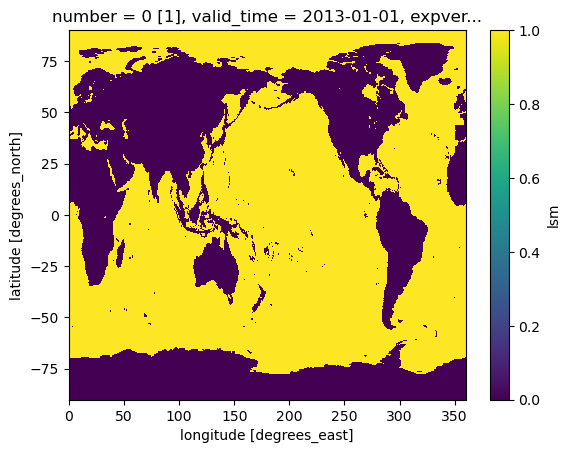

In [4]:
ds_static = xr.open_dataset('/glade/derecho/scratch/turuncu/data/static.nc')
lsm = ds_static.lsm.isel(valid_time=0)
dmask = (lsm == 0)
dmask.plot()

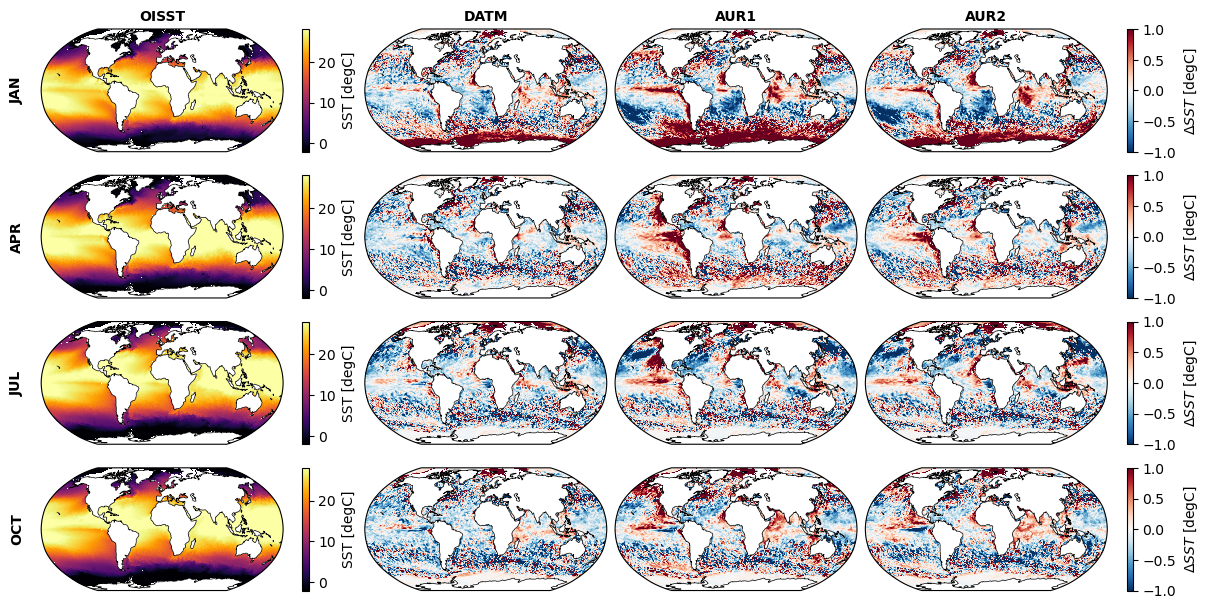

In [5]:
fig, ax = plt.subplots(4, 4, figsize=(12, 6), layout='constrained', subplot_kw={'projection': ccrs.Robinson()})

irow = 0
for label, val in months.items():
    # Load datasets
    ds_oisst_mean= xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_oisst/oisst_35d_remap_bil_tmean.nc")).isel(zlev=0)
    #ds_datm_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_datm/ocn_merged_35d_remap_bil_tmean.nc"))
    ds_datm_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora/ocn_merged_35d_remap_bil_tmean.nc"))
    ds_aur1_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_r2/ocn_merged_35d_remap_bil_tmean.nc"))
    ds_aur2_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_two_way_r4/ocn_merged_35d_remap_bil_tmean.nc"))

    # Create mask
    dmask = ds_datm_mean.SST.notnull()

    # OISST
    data_oisst = ds_oisst_mean.sst.where(dmask).isel(time=0)
    im0 = data_oisst.plot(ax=ax[irow,0], transform=ccrs.PlateCarree(), vmin=-2, vmax=28, cmap='inferno', add_colorbar=False)
    ax[irow,0].coastlines(linewidth=0.5)
    fig.colorbar(im0, ax=ax[irow,0], pad=0.08, aspect=20, shrink=0.9, label='SST [degC]')

    # MOM6: ERA5 forced
    data_datm = ds_datm_mean.SST.where(dmask).isel(time=0)
    data_datm = data_datm-data_oisst
    im1 = data_datm.plot(ax=ax[irow,1], transform=ccrs.PlateCarree(), vmin=-1, vmax=1, cmap='RdBu_r', add_colorbar=False)
    ax[irow,1].coastlines(linewidth=0.5)

    # MOM6: Aurora forced (1-way)
    data_aur1 = ds_aur1_mean.SST.where(dmask).isel(time=0)
    data_aur1 = data_aur1-data_oisst
    im2 = data_aur1.plot(ax=ax[irow,2], transform=ccrs.PlateCarree(), vmin=-1, vmax=1, cmap='RdBu_r', add_colorbar=False)
    ax[irow,2].coastlines(linewidth=0.5)

    # MOM6: Aurora forced (2-way)
    data_aur2 = ds_aur2_mean.SST.where(dmask).isel(time=0)
    data_aur2 = data_aur2-data_oisst
    im3 = data_aur2.plot(ax=ax[irow,3], transform=ccrs.PlateCarree(), vmin=-1, vmax=1, cmap='RdBu_r', add_colorbar=False)
    ax[irow,3].coastlines(linewidth=0.5)
    fig.colorbar(im3, ax=ax[irow,3], pad=0.08, aspect=20, shrink=0.9, label=r'$\Delta SST$ [degC]')

    # Labels
    if irow == 0:
        ax[irow,0].set_title("OISST", fontweight='bold', fontsize=10)
        ax[irow,1].set_title("DATM", fontweight='bold', fontsize=10)
        ax[irow,2].set_title("AUR1", fontweight='bold', fontsize=10)
        ax[irow,3].set_title("AUR2", fontweight='bold', fontsize=10)
    else:
        ax[irow,0].set_title("")
        ax[irow,1].set_title("")
        ax[irow,2].set_title("")
        ax[irow,3].set_title("")

    ax[irow,0].text(-0.1, 0.5, f"{label}", transform=ax[irow,0].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

    irow = irow+1

filename = f"sst.png"
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)

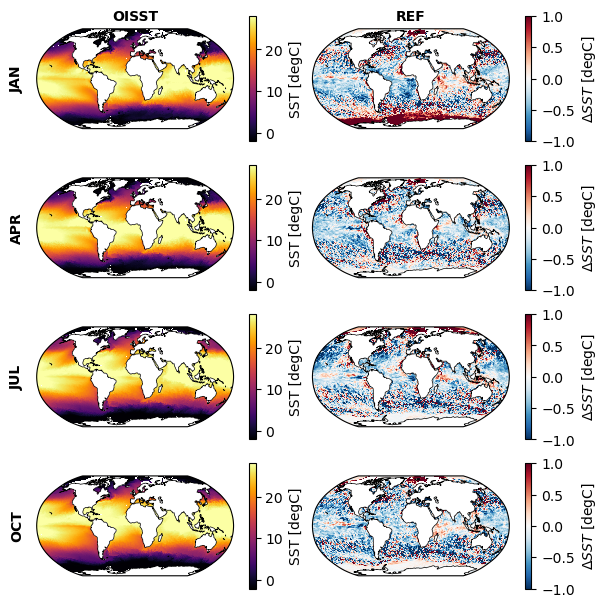

In [10]:
fig, ax = plt.subplots(4, 2, figsize=(6, 6), layout='constrained', subplot_kw={'projection': ccrs.Robinson()})

irow = 0
for label, val in months.items():
    # Load datasets
    ds_oisst_mean= xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_oisst/oisst_35d_remap_bil_tmean.nc")).isel(zlev=0)
    ds_datm_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_datm/ocn_merged_35d_remap_bil_tmean.nc"))

    # Create mask
    dmask = ds_datm_mean.SST.notnull()

    # OISST
    data_oisst = ds_oisst_mean.sst.where(dmask).isel(time=0)
    im0 = data_oisst.plot(ax=ax[irow,0], transform=ccrs.PlateCarree(), vmin=-2, vmax=28, cmap='inferno', add_colorbar=False)
    ax[irow,0].coastlines(linewidth=0.5)
    fig.colorbar(im0, ax=ax[irow,0], pad=0.08, aspect=20, shrink=0.9, label='SST [degC]')

    # MOM6: ERA5 forced
    data_datm = ds_datm_mean.SST.where(dmask).isel(time=0)
    data_datm = data_datm-data_oisst
    im1 = data_datm.plot(ax=ax[irow,1], transform=ccrs.PlateCarree(), vmin=-1, vmax=1, cmap='RdBu_r', add_colorbar=False)
    ax[irow,1].coastlines(linewidth=0.5)
    fig.colorbar(im1, ax=ax[irow,1], pad=0.08, aspect=20, shrink=0.9, label=r'$\Delta SST$ [degC]')

    # Labels
    if irow == 0:
        ax[irow,0].set_title("OISST", fontweight='bold', fontsize=10)
        ax[irow,1].set_title("REF", fontweight='bold', fontsize=10)
    else:
        ax[irow,0].set_title("")
        ax[irow,1].set_title("")

    ax[irow,0].text(-0.1, 0.5, f"{label}", transform=ax[irow,0].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

    irow = irow+1

filename = f"sst.png"
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)

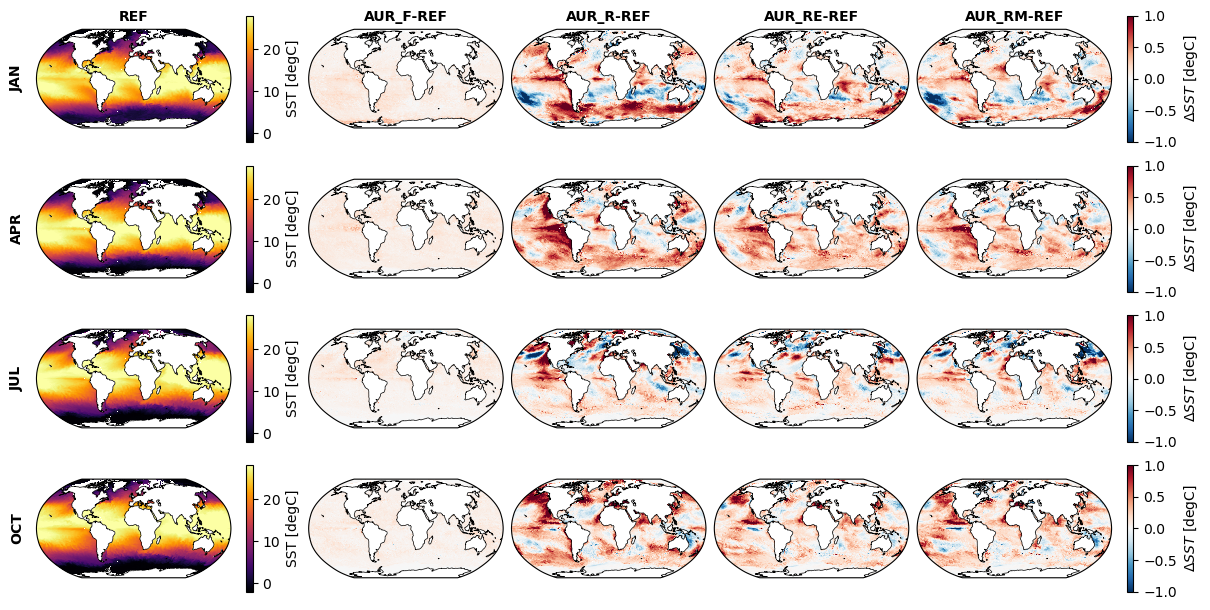

In [7]:
data_path = "/glade/derecho/scratch/turuncu/data/Run_global/postprocessed"

months = {
    "JAN": 1,
    "APR": 4,
    "JUL": 7,
    "OCT": 10
}

fig, ax = plt.subplots(4, 5, figsize=(12, 6), layout='constrained', subplot_kw={'projection': ccrs.Robinson()})

irow = 0
for label, val in months.items():
    # Load datasets
    ds_datm_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_datm/ocn_merged_35d_remap_bil_tmean.nc"))
    ds_aur1_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora/ocn_merged_35d_remap_bil_tmean.nc"))
    ds_aur2_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_r2/ocn_merged_35d_remap_bil_tmean.nc"))
    ds_aur3_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_r3/ocn_merged_35d_remap_bil_tmean.nc"))
    ds_aur4_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_two_way_r4/ocn_merged_35d_remap_bil_tmean.nc"))

    # REF - forced with CDEPS ERA5
    data_datm = ds_datm_mean.SST.isel(time=0)
    im0 = data_datm.plot(ax=ax[irow,0], transform=ccrs.PlateCarree(), vmin=-2, vmax=28, cmap='inferno', add_colorbar=False)
    ax[irow,0].coastlines(linewidth=0.5)
    fig.colorbar(im0, ax=ax[irow,0], pad=0.08, aspect=20, shrink=0.9, label='SST [degC]')

    # AUR_F - forced with ERA5
    data_aur1 = ds_aur1_mean.SST.isel(time=0)
    data_aur1 = data_aur1-data_datm
    im1 = data_aur1.plot(ax=ax[irow,1], transform=ccrs.PlateCarree(), vmin=-1, vmax=1, cmap='RdBu_r', add_colorbar=False)
    ax[irow,1].coastlines(linewidth=0.5)
    
    # AUR_R - autoregressive rollout
    data_aur2 = ds_aur2_mean.SST.isel(time=0)
    data_aur2 = data_aur2-data_datm
    im2 = data_aur2.plot(ax=ax[irow,2], transform=ccrs.PlateCarree(), vmin=-1, vmax=1, cmap='RdBu_r', add_colorbar=False)
    ax[irow,2].coastlines(linewidth=0.5)

    # AUR_RE - autoregressive rollout SST is replaced with ERA5
    data_aur3 = ds_aur3_mean.SST.isel(time=0)
    data_aur3 = data_aur3-data_datm
    im3 = data_aur3.plot(ax=ax[irow,3], transform=ccrs.PlateCarree(), vmin=-1, vmax=1, cmap='RdBu_r', add_colorbar=False)
    ax[irow,3].coastlines(linewidth=0.5)

    # AUR_RM - autoregressive rollout SST is replaced with MOM6 SST
    data_aur4 = ds_aur4_mean.SST.isel(time=0)
    data_aur4 = data_aur4-data_datm
    im4 = data_aur4.plot(ax=ax[irow,4], transform=ccrs.PlateCarree(), vmin=-1, vmax=1, cmap='RdBu_r', add_colorbar=False)
    ax[irow,4].coastlines(linewidth=0.5)
    fig.colorbar(im4, ax=ax[irow,4], pad=0.08, aspect=20, shrink=0.9, label=r'$\Delta SST$ [degC]')

    # Labels
    if irow == 0:
        ax[irow,0].set_title("REF", fontweight='bold', fontsize=10)
        ax[irow,1].set_title("AUR_F-REF", fontweight='bold', fontsize=10)
        ax[irow,2].set_title("AUR_R-REF", fontweight='bold', fontsize=10)
        ax[irow,3].set_title("AUR_RE-REF", fontweight='bold', fontsize=10)
        ax[irow,4].set_title("AUR_RM-REF", fontweight='bold', fontsize=10)
    else:
        ax[irow,0].set_title("")
        ax[irow,1].set_title("")
        ax[irow,2].set_title("")
        ax[irow,3].set_title("")
        ax[irow,4].set_title("")

    ax[irow,0].text(-0.1, 0.5, f"{label}", transform=ax[irow,0].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

    irow = irow+1

# Save to file
filename = "sst_spatial_vs_ref.png"
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)

In [ ]:
data_path = "/glade/derecho/scratch/turuncu/data/Run_global/postprocessed"

months = {
    "JAN": 1,
    "APR": 4,
    "JUL": 7,
    "OCT": 10
}

fig, ax = plt.subplots(4, 4, figsize=(12, 6), layout='constrained', subplot_kw={'projection': ccrs.Robinson()})

irow = 0
for label, val in months.items():
    # Load datasets
    ds_aur1_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora/ocn_merged_35d_remap_bil_tmean.nc"))
    ds_aur2_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_r2/ocn_merged_35d_remap_bil_tmean.nc"))
    ds_aur3_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_r3/ocn_merged_35d_remap_bil_tmean.nc"))
    ds_aur4_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_two_way_r4/ocn_merged_35d_remap_bil_tmean.nc"))

    # REF - forced with ERA5
    data_aur1 = ds_aur1_mean.SST.isel(time=0)
    im0 = data_aur1.plot(ax=ax[irow,0], transform=ccrs.PlateCarree(), vmin=-2, vmax=28, cmap='inferno', add_colorbar=False)
    ax[irow,0].coastlines(linewidth=0.5)
    fig.colorbar(im0, ax=ax[irow,0], pad=0.08, aspect=20, shrink=0.9, label='SST [degC]')

    # FREE - autoregressive rollout
    data_aur2 = ds_aur2_mean.SST.isel(time=0)
    data_aur2 = data_aur2-data_aur1
    im1 = data_aur2.plot(ax=ax[irow,1], transform=ccrs.PlateCarree(), vmin=-1, vmax=1, cmap='RdBu_r', add_colorbar=False)
    ax[irow,1].coastlines(linewidth=0.5)

    # FREE - autoregressive rollout SST is replaced with ERA5
    data_aur3 = ds_aur3_mean.SST.isel(time=0)
    data_aur3 = data_aur3-data_aur1
    im2 = data_aur3.plot(ax=ax[irow,2], transform=ccrs.PlateCarree(), vmin=-1, vmax=1, cmap='RdBu_r', add_colorbar=False)
    ax[irow,2].coastlines(linewidth=0.5)

    # FREE - autoregressive rollout SST is replaced with MOM6 SST
    data_aur4 = ds_aur4_mean.SST.isel(time=0)
    data_aur4 = data_aur4-data_aur1
    im3 = data_aur4.plot(ax=ax[irow,3], transform=ccrs.PlateCarree(), vmin=-1, vmax=1, cmap='RdBu_r', add_colorbar=False)
    ax[irow,3].coastlines(linewidth=0.5)
    fig.colorbar(im1, ax=ax[irow,3], pad=0.08, aspect=20, shrink=0.9, label=r'$\Delta SST$ [degC]')

    # Labels
    if irow == 0:
        ax[irow,0].set_title("REF", fontweight='bold', fontsize=10)
        ax[irow,1].set_title("AUR_R-REF", fontweight='bold', fontsize=10)
        ax[irow,2].set_title("AUR_RE-REF", fontweight='bold', fontsize=10)
        ax[irow,3].set_title("AUR_RM-REF", fontweight='bold', fontsize=10)
    else:
        ax[irow,0].set_title("")
        ax[irow,1].set_title("")
        ax[irow,2].set_title("")
        ax[irow,3].set_title("")

    ax[irow,0].text(-0.1, 0.5, f"{label}", transform=ax[irow,0].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

    irow = irow+1

# Save to file
filename = "sst_spatial_vs_ref.png"
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)

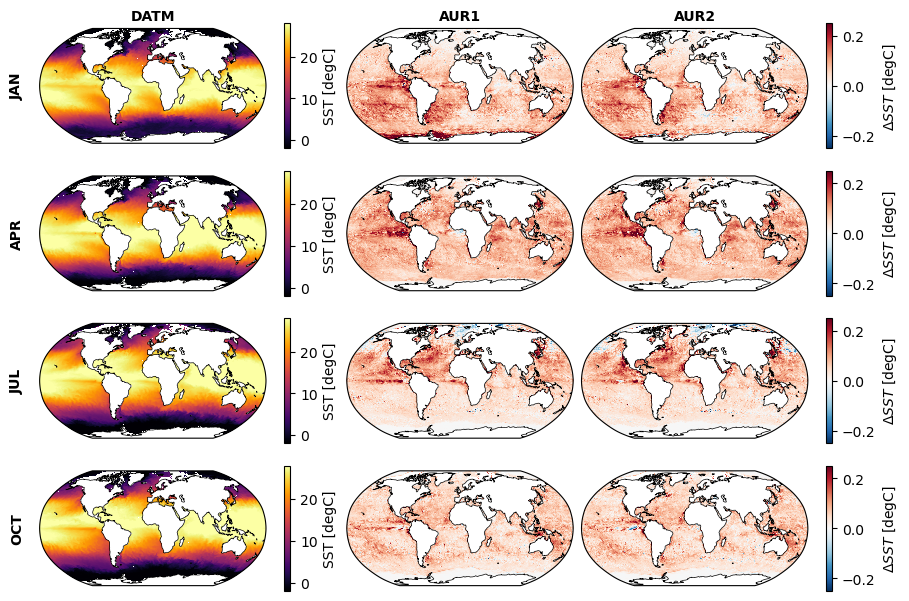

In [21]:
fig, ax = plt.subplots(4, 3, figsize=(9, 6), layout='constrained', subplot_kw={'projection': ccrs.Robinson()})

irow = 0
for label, val in months.items():
    # Load datasets
    ds_datm_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_datm/ocn_merged_35d_remap_bil_tmean.nc"))
    ds_aur1_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora/ocn_merged_35d_remap_bil_tmean.nc"))
    ds_aur2_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_two_way/ocn_merged_35d_remap_bil_tmean.nc"))

    # Create mask
    dmask = ds_datm_mean.SST.notnull()

    # MOM6: ERA5 forced
    data_datm = ds_datm_mean.SST.where(dmask).isel(time=0)
    im0 = data_datm.plot(ax=ax[irow,0], transform=ccrs.PlateCarree(), vmin=-2, vmax=28, cmap='inferno', add_colorbar=False)
    ax[irow,0].coastlines(linewidth=0.5)
    fig.colorbar(im0, ax=ax[irow,0], pad=0.08, aspect=20, shrink=0.9, label='SST [degC]')

    # MOM6: Aurora forced (1-way)
    data_aur1 = ds_aur1_mean.SST.where(dmask).isel(time=0)
    data_aur1 = data_aur1-data_datm
    im1 = data_aur1.plot(ax=ax[irow,1], transform=ccrs.PlateCarree(), vmin=-0.25, vmax=0.25, cmap='RdBu_r', add_colorbar=False)
    ax[irow,1].coastlines(linewidth=0.5)

    # MOM6: Aurora forced (2-way)
    data_aur2 = ds_aur2_mean.SST.where(dmask).isel(time=0)
    data_aur2 = data_aur2-data_datm
    im2 = data_aur2.plot(ax=ax[irow,2], transform=ccrs.PlateCarree(), vmin=-0.25, vmax=0.25, cmap='RdBu_r', add_colorbar=False)
    ax[irow,2].coastlines(linewidth=0.5)
    fig.colorbar(im2, ax=ax[irow,2], pad=0.08, aspect=20, shrink=0.9, label=r'$\Delta SST$ [degC]')

    # Labels
    if irow == 0:
        ax[irow,0].set_title("DATM", fontweight='bold', fontsize=10)
        ax[irow,1].set_title("AUR1", fontweight='bold', fontsize=10)
        ax[irow,2].set_title("AUR2", fontweight='bold', fontsize=10)
    else:
        ax[irow,0].set_title("")
        ax[irow,1].set_title("")
        ax[irow,2].set_title("")

    ax[irow,0].text(-0.1, 0.5, f"{label}", transform=ax[irow,0].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

    irow = irow+1

filename = f"sst_diff_aur.png"
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)

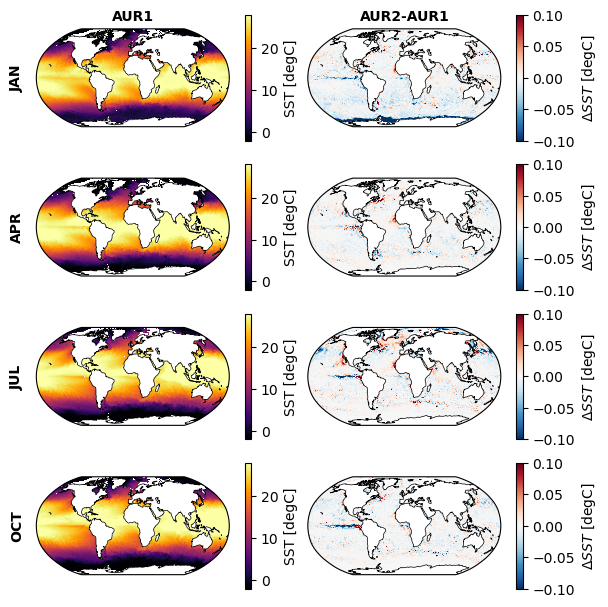

In [11]:
fig, ax = plt.subplots(4, 2, figsize=(6, 6), layout='constrained', subplot_kw={'projection': ccrs.Robinson()})

irow = 0
for label, val in months.items():
    # Load datasets
    ds_aur1_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora/ocn_merged_35d_remap_bil_tmean.nc"))
    ds_aur2_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_two_way/ocn_merged_35d_remap_bil_tmean.nc"))

    # MOM6: Aurora forced (1-way)
    data_aur1 = ds_aur1_mean.SST.isel(time=0)
    im0 = data_aur1.plot(ax=ax[irow,0], transform=ccrs.PlateCarree(), vmin=-2, vmax=28, cmap='inferno', add_colorbar=False)
    ax[irow,0].coastlines(linewidth=0.5)
    fig.colorbar(im0, ax=ax[irow,0], pad=0.08, aspect=20, shrink=0.9, label='SST [degC]')

    # MOM6: Aurora forced (2-way)
    data_aur2 = ds_aur2_mean.SST.isel(time=0)
    data_aur2 = data_aur2-data_aur1
    im1 = data_aur2.plot(ax=ax[irow,1], transform=ccrs.PlateCarree(), vmin=-0.1, vmax=0.1, cmap='RdBu_r', add_colorbar=False)
    ax[irow,1].coastlines(linewidth=0.5)
    fig.colorbar(im1, ax=ax[irow,1], pad=0.08, aspect=20, shrink=0.9, label=r'$\Delta SST$ [degC]')

    # Labels
    if irow == 0:
        ax[irow,0].set_title("AUR1", fontweight='bold', fontsize=10)
        ax[irow,1].set_title("AUR2-AUR1", fontweight='bold', fontsize=10)
    else:
        ax[irow,0].set_title("")
        ax[irow,1].set_title("")

    ax[irow,0].text(-0.1, 0.5, f"{label}", transform=ax[irow,0].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

    irow = irow+1

# Save to file
filename = "diff_aur2-aur1_sst.png"
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)

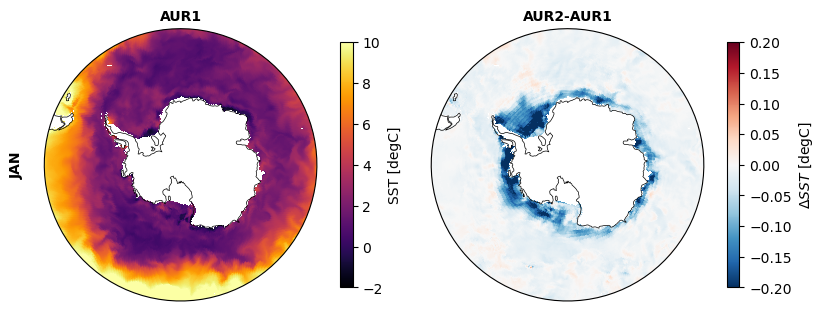

In [10]:
import matplotlib.path as mpath

# Make circular boundary for polar stereographic circular plots
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

# Create figure
proj  = ccrs.SouthPolarStereo()
fig, ax = plt.subplots(1, 2, figsize=(8, 3), layout='constrained', subplot_kw={'projection': proj})

# Month
mm = 1
label = "JAN"

# Load datasets
ds_aur1_mean = xr.open_dataset(os.path.join(data_path, f"2021{mm:02d}01_aurora/ocn_merged_35d_remap_bil_tmean.nc"))
ds_aur2_mean = xr.open_dataset(os.path.join(data_path, f"2021{mm:02d}01_aurora_two_way/ocn_merged_35d_remap_bil_tmean.nc"))

# MOM6: Aurora forced (1-way)
data_aur1 = ds_aur1_mean.SST.isel(time=0)
im0 = data_aur1.plot(ax=ax[0], transform=ccrs.PlateCarree(), vmin=-2, vmax=10, cmap='inferno', add_colorbar=False)
ax[0].coastlines(linewidth=0.5)
ax[0].set_boundary(circle, transform=ax[0].transAxes)
ax[0].set_extent([-180, 180, -50, -90], ccrs.PlateCarree())
fig.colorbar(im0, ax=ax[0], pad=0.08, aspect=20, shrink=0.9, label='SST [degC]')

# MOM6: Aurora forced (2-way)
data_aur2 = ds_aur2_mean.SST.isel(time=0)
data_aur2 = data_aur2-data_aur1
im1 = data_aur2.plot(ax=ax[1], transform=ccrs.PlateCarree(), vmin=-0.2, vmax=0.2, cmap='RdBu_r', add_colorbar=False)
ax[1].coastlines(linewidth=0.5)
ax[1].set_boundary(circle, transform=ax[1].transAxes)
ax[1].set_extent([-180, 180, -50, -90], ccrs.PlateCarree())
fig.colorbar(im1, ax=ax[1], pad=0.08, aspect=20, shrink=0.9, label=r'$\Delta SST$ [degC]')

# Labels
ax[0].set_title("AUR1", fontweight='bold', fontsize=10)
ax[1].set_title("AUR2-AUR1", fontweight='bold', fontsize=10)
ax[0].text(-0.1, 0.5, f"{label}", transform=ax[0].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

# Save to file
filename = "added_value_sh_sst.png"
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)

Text(-0.1, 0.5, 'JUL')

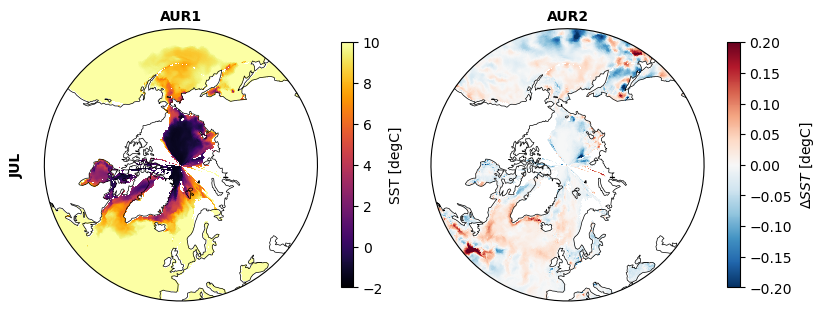

In [6]:
import matplotlib.path as mpath

# Make circular boundary for polar stereographic circular plots
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

# Create figure
proj  = ccrs.NorthPolarStereo()
fig, ax = plt.subplots(1, 2, figsize=(8, 3), layout='constrained', subplot_kw={'projection': proj})

# Month
mm = 7
label = "JUL"

# Load datasets
ds_aur1_mean = xr.open_dataset(os.path.join(data_path, f"2021{mm:02d}01_aurora/ocn_merged_35d_remap_bil_tmean.nc"))
ds_aur2_mean = xr.open_dataset(os.path.join(data_path, f"2021{mm:02d}01_aurora_two_way/ocn_merged_35d_remap_bil_tmean.nc"))

# MOM6: Aurora forced (1-way)
data_aur1 = ds_aur1_mean.SST.isel(time=0)
im0 = data_aur1.plot(ax=ax[0], transform=ccrs.PlateCarree(), vmin=-2, vmax=10, cmap='inferno', add_colorbar=False)
ax[0].coastlines(linewidth=0.5)
ax[0].set_boundary(circle, transform=ax[0].transAxes)
ax[0].set_extent([-180, 180, 40, 90], ccrs.PlateCarree())
fig.colorbar(im0, ax=ax[0], pad=0.08, aspect=20, shrink=0.9, label='SST [degC]')

# MOM6: Aurora forced (2-way)
data_aur2 = ds_aur2_mean.SST.isel(time=0)
data_aur2 = data_aur2-data_aur1
im1 = data_aur2.plot(ax=ax[1], transform=ccrs.PlateCarree(), vmin=-0.2, vmax=0.2, cmap='RdBu_r', add_colorbar=False)
ax[1].coastlines(linewidth=0.5)
ax[1].set_boundary(circle, transform=ax[1].transAxes)
ax[1].set_extent([-180, 180, 40, 90], ccrs.PlateCarree())
fig.colorbar(im1, ax=ax[1], pad=0.08, aspect=20, shrink=0.9, label=r'$\Delta SST$ [degC]')

# Labels
ax[0].set_title("AUR1", fontweight='bold', fontsize=10)
ax[1].set_title("AUR2", fontweight='bold', fontsize=10)
ax[0].text(-0.1, 0.5, f"{label}", transform=ax[0].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

In [12]:
# from https://github.com/google-research/weatherbench2/blob/021c0b33d9dd165d1e7aa476fcc985be855fbc7b/weatherbench2/metrics.py#L40
def _latitude_cell_bounds(x: np.ndarray) -> np.ndarray:
  pi_over_2 = np.array([np.pi / 2], dtype=x.dtype)
  return np.concatenate([-pi_over_2, (x[:-1] + x[1:]) / 2, pi_over_2])
    
# From https://github.com/google-research/weatherbench2/blob/021c0b33d9dd165d1e7aa476fcc985be855fbc7b/weatherbench2/metrics.py#L45
def _cell_area_from_latitude(points: np.ndarray) -> np.ndarray:
  """Calculate the area overlap as a function of latitude."""
  bounds = _latitude_cell_bounds(points)
  upper = bounds[1:]
  lower = bounds[:-1]
  # normalized cell area: integral from lower to upper of cos(latitude)
  return np.sin(upper) - np.sin(lower)

# From https://github.com/google-research/weatherbench2/blob/021c0b33d9dd165d1e7aa476fcc985be855fbc7b/weatherbench2/metrics.py#L55
def get_lat_weights(ds: xr.Dataset) -> xr.DataArray:
  """Computes latitude/area weights from latitude coordinate of dataset."""
  weights = _cell_area_from_latitude(np.deg2rad(ds.latitude.data))
  weights /= np.mean(weights)
  weights = ds.latitude.copy(data=weights)
  return weights

In [13]:
regions = {
    "Global": {"lat_min": -90, "lat_max": 90, "lon_min": 0, "lon_max": 360},
    "Global Land": {"lat_min": -90, "lat_max": 90, "lon_min": 0, "lon_max": 360, "over_land": True},
    "Global Ocean": {"lat_min": -90, "lat_max": 90, "lon_min": 0, "lon_max": 360, "over_ocean": True},
    "Europe": {"lat_min": 35, "lat_max": 70, "lon_min": -10, "lon_max": 40, "over_land": True}, # 35N-70N, 10W-40E
    "North America": {"lat_min": 15, "lat_max": 70, "lon_min": 198, "lon_max": 309, "over_land": True}, # 15N-75N, 140W-50W
    "South America": {"lat_min": -60, "lat_max": 15, "lon_min": 280, "lon_max": 330, "over_land": True}, # 60S-15N, 80W-30W
    "Africa": {"lat_min": -35, "lat_max": 35, "lon_min": -20, "lon_max": 55, "over_land": True}, # 35S-35N, 20W-55E
    "Asia": {"lat_min": 30, "lat_max": 75, "lon_min": 55, "lon_max": 190, "over_land": True}, # 5N-55N, 55E-180E
    "Australia": {"lat_min": -45, "lat_max": -10, "lon_min": 110, "lon_max": 155, "over_land": True}, # 45S-10S, 110E-155E
    "Tropics": {"lat_min": -20, "lat_max": 20, "lon_min": 0, "lon_max": 360}, # 20S-20N, global
    "Nino 1+2": {"lat_min": -10, "lat_max": 0, "lon_min":270 , "lon_max": 280, "over_ocean": True}, # 10S-0N, 90W-80W
    "Nino 3": {"lat_min": -5, "lat_max": 5, "lon_min": 210, "lon_max": 270, "over_ocean": True}, # 5N-5S, 150W-90W
    "Nino 3.4": {"lat_min": -5, "lat_max": 5, "lon_min": 190, "lon_max": 240, "over_ocean": True}, # 5N-5S, 170W-120W
    "Nino 4": {"lat_min": -5, "lat_max": 5, "lon_min": 160, "lon_max": 210, "over_ocean": True}, # 5N-5S, 160E-150W
    "Gulf of Mexico": {"lat_min": 18, "lat_max": 30, "lon_min": 263, "lon_max": 278, "over_ocean": True}, # 18N-30N, 97W-82W
    "North Atlantic Ocean": {"lat_min": 0, "lat_max": 60, "lon_min": 280, "lon_max": 360, "over_ocean": True}, # 0N-60N, 80W-0E
    "Indian Ocean": {"lat_min": -40, "lat_max": 30, "lon_min": 20, "lon_max": 120, "over_ocean": True}, # 40S-30N, 20E-120E
    "Western Pacific Ocean": {"lat_min": -10, "lat_max": 30, "lon_min": 120, "lon_max": 160, "over_ocean": True}, # 10S-30N, 120E-160E
    "Eastern Pacific Ocean": {"lat_min": -10, "lat_max": 30, "lon_min": 240, "lon_max": 280, "over_ocean": True}, # 10S-30N, 120W-80W
    "Southern Ocean": {"lat_min": -90, "lat_max": -60, "lon_min": 0, "lon_max": 360, "over_ocean": True}, # 90S-60S, global
    "Arctic Ocean": {"lat_min": 60, "lat_max": 90, "lon_min": 0, "lon_max": 360, "over_ocean": True}, # 60N-90N, global
    "Antarctic Ocean": {"lat_min": -90, "lat_max": -50, "lon_min": 0, "lon_max": 360, "over_ocean": True}, # 50S-90S, global
}

# Set list of regions
region_list = { 
    "Global": [0.68, 0.02, 0.3, 0.3],
    "Nino 1+2": [0.68, 0.02, 0.3, 0.3],
    "Nino 3": [0.68, 0.02, 0.3, 0.3],
    "Nino 4": [0.02, 0.02, 0.3, 0.3],
    "Nino 3.4": [0.02, 0.02, 0.3, 0.3],
    "Indian Ocean": [0.68, 0.02, 0.6, 0.6],
    "Western Pacific Ocean": [0.02, 0.02, 0.3, 0.3],
    "Eastern Pacific Ocean": [0.02, 0.02, 0.3, 0.3]
}

JAN 1
ERA5 - RMSE = 0.49494529057429976, CORR = 0.9853954911231995
DATM - RMSE = 1.212220710175007, CORR = 0.916030764579773
AUR0 - RMSE = 1.2153559286823656, CORR = 0.9158619046211243
AUR1 - RMSE = 1.2297674600244546, CORR = 0.9142404794692993
AUR2 - RMSE = 1.223499244172553, CORR = 0.9143639206886292
AUR3 - RMSE = 1.2221254527632617, CORR = 0.9141772389411926
APR 4
ERA5 - RMSE = 0.40034021537218323, CORR = 0.9901148080825806
DATM - RMSE = 1.091168080784773, CORR = 0.9249672889709473
AUR0 - RMSE = 1.094266546514922, CORR = 0.9249264597892761
AUR1 - RMSE = 1.0952128824018375, CORR = 0.9278960227966309
AUR2 - RMSE = 1.1085057428661784, CORR = 0.9226407408714294
AUR3 - RMSE = 1.135053714092377, CORR = 0.9216315150260925
JUL 7
ERA5 - RMSE = 0.8690144793699073, CORR = 0.9855484962463379
DATM - RMSE = 2.6819400346599735, CORR = 0.8181672096252441
AUR0 - RMSE = 2.6769863895026944, CORR = 0.8199968338012695
AUR1 - RMSE = 2.917577536961614, CORR = 0.7951423525810242
AUR2 - RMSE = 2.66429505846

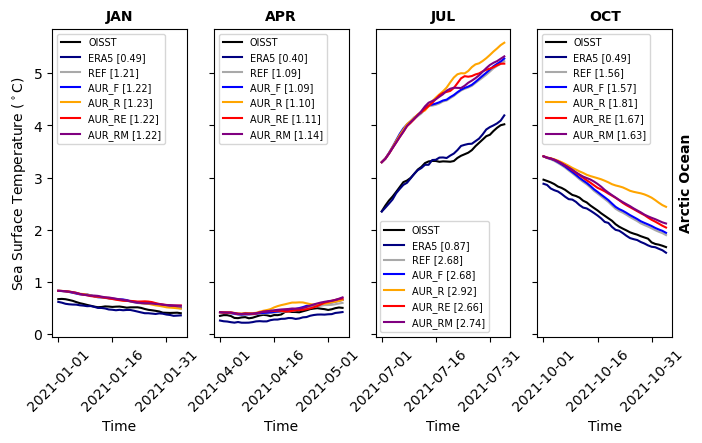

In [15]:
# Set region
#reg = "Southern Ocean"
#reg = "Global"
#reg = "Arctic Ocean"
#reg = "North Atlantic Ocean"
#reg = "Nino 3.4"
#reg = "Nino 4"
#reg = "Nino 3"
#reg = "Western Pacific Ocean"
#reg = "Eastern Pacific Ocean"
#reg = "Global Ocean"
reg = "Tropics"
reg = "Indian Ocean"
reg = "Arctic Ocean"

# Create composite time axis
t1 = pd.date_range(start='2021-01-01', end='2021-02-04', freq='1d').strftime('%Y-%m-%dT%H:%M:%S').to_list()
t2 = pd.date_range(start='2021-04-01', end='2021-05-05', freq='1d').strftime('%Y-%m-%dT%H:%M:%S').to_list()
t3 = pd.date_range(start='2021-07-01', end='2021-08-04', freq='1d').strftime('%Y-%m-%dT%H:%M:%S').to_list()
t4 = pd.date_range(start='2021-10-01', end='2021-11-04', freq='1d').strftime('%Y-%m-%dT%H:%M:%S').to_list()
time_arr = t1+t2+t3+t4

fig, ax = plt.subplots(1, 4, figsize=(8, 4), sharey=True)#, layout='constrained')

indx = 0
for label, val in months.items():
    print(label, val)
    # Load datasets
    ds_era5_daily = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_era5/era5_35d_sst_daily.nc")).drop_vars(['valid_time_bnds']).rename_dims({'valid_time': 'time'})
    ds_oisst_daily= xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_oisst/oisst_35d_remap_bil.nc")).squeeze(drop=True)
    ds_datm_daily = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_datm/ocn_merged_35d_remap_bil_daily.nc")).rename({'SST': 'sst'})
    ds_aur0_daily = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora/ocn_merged_35d_remap_bil_daily.nc")).rename({'SST': 'sst'})
    ds_aur1_daily = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_r2/ocn_merged_35d_remap_bil_daily.nc")).rename({'SST': 'sst'})
    ds_aur2_daily = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_r3/ocn_merged_35d_remap_bil_daily.nc")).rename({'SST': 'sst'})
    ds_aur3_daily = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_two_way_r4/ocn_merged_35d_remap_bil_daily.nc")).rename({'SST': 'sst'})

    ds_era5_daily = ds_era5_daily.reindex(latitude=ds_era5_daily.latitude[::-1])
    ds_oisst_daily= ds_oisst_daily.reindex(latitude=ds_oisst_daily.latitude[::-1])
    ds_datm_daily = ds_datm_daily.reindex(latitude=ds_datm_daily.latitude[::-1])
    ds_aur0_daily = ds_aur0_daily.reindex(latitude=ds_aur0_daily.latitude[::-1])
    ds_aur1_daily = ds_aur1_daily.reindex(latitude=ds_aur1_daily.latitude[::-1])
    ds_aur2_daily = ds_aur2_daily.reindex(latitude=ds_aur2_daily.latitude[::-1])
    ds_aur3_daily = ds_aur3_daily.reindex(latitude=ds_aur3_daily.latitude[::-1])

    # Calculate weights
    weights = get_lat_weights(ds_era5_daily)
    weights2d = xr.DataArray(np.tile(weights.values[:,np.newaxis], (1, ds_era5_daily.longitude.size)))
    ds_era5_daily["weights"] = (("latitude", "longitude"), weights2d.data)
    weights = np.cos(np.deg2rad(ds_era5_daily.latitude))
    weights = weights / weights.mean()
    weights2d = xr.DataArray(np.tile(weights.values[:,np.newaxis], (1, ds_era5_daily.longitude.size)))
    ds_era5_daily["weights2"] = (("latitude", "longitude"), weights2d.data)

    # Get region extent
    lat_min = regions[reg]['lat_min']
    lat_max = regions[reg]['lat_max']
    lon_min = regions[reg]['lon_min']
    lon_max = regions[reg]['lon_max']

    # Subset datasets
    ds_era5_subset = ds_era5_daily.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
    ds_oisst_subset = ds_oisst_daily.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
    ds_datm_subset = ds_datm_daily.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
    ds_aur0_subset = ds_aur0_daily.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
    ds_aur1_subset = ds_aur1_daily.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
    ds_aur2_subset = ds_aur2_daily.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
    ds_aur3_subset = ds_aur3_daily.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))

    # Perfrom unit conversions
    ds_era5_subset['sst'] = ds_era5_subset['sst']-273.15

    # Calculate correlation and RMSE
    data = {
        "ERA5": ds_era5_subset,
        "DATM": ds_datm_subset,
        "AUR0": ds_aur0_subset,
        "AUR1": ds_aur1_subset,
        "AUR2": ds_aur2_subset,
        "AUR3": ds_aur3_subset
    }
    RMSE_dict = {}
    CORR_dict = {}
    for label2, d in data.items():
        RMSE = np.sqrt(((d.sst - ds_oisst_subset.sst) ** 2).weighted(weights).mean(dim=['latitude', 'longitude']))
        RMSE = RMSE.mean(dim=['time']).values
        RMSE_dict[label2] = RMSE
        CORR = xs.pearson_r(ds_oisst_subset.sst, d.sst, skipna=True, dim=['latitude', 'longitude'])
        CORR = CORR.mean(dim=['time']).values
        CORR_dict[label2] = CORR
        print(f"{label2} - RMSE = {RMSE_dict[label2]}, CORR = {CORR_dict[label2]}")

    # Create mask
    dmask = ds_datm_subset.sst.notnull()
    
    # Calculate area weighted mean
    data_era5 = ds_era5_subset.sst.where(dmask).weighted(ds_era5_subset.weights).mean(dim=["longitude", "latitude"])
    data_oisst = ds_oisst_subset.sst.where(dmask).weighted(ds_era5_subset.weights).mean(dim=["longitude", "latitude"])
    data_datm = ds_datm_subset.sst.where(dmask).weighted(ds_era5_subset.weights).mean(dim=["longitude", "latitude"])
    data_aur0 = ds_aur0_subset.sst.where(dmask).weighted(ds_era5_subset.weights).mean(dim=["longitude", "latitude"])
    data_aur1 = ds_aur1_subset.sst.where(dmask).weighted(ds_era5_subset.weights).mean(dim=["longitude", "latitude"])
    data_aur2 = ds_aur2_subset.sst.where(dmask).weighted(ds_era5_subset.weights).mean(dim=["longitude", "latitude"])
    data_aur3 = ds_aur3_subset.sst.where(dmask).weighted(ds_era5_subset.weights).mean(dim=["longitude", "latitude"])

    # Plot
    time = data_datm.time.values
    ax[indx].plot(time, data_oisst, color='black', label="OISST")
    ax[indx].plot(time, data_era5, color='navy', label=f"ERA5 [{RMSE_dict['ERA5']:.2f}]")
    ax[indx].plot(time, data_datm, color='darkgray', label=f"REF [{RMSE_dict['DATM']:.2f}]")
    ax[indx].plot(time, data_aur0, color='blue', label=f"AUR_F [{RMSE_dict['AUR0']:.2f}]")
    ax[indx].plot(time, data_aur1, color='orange', label=f"AUR_R [{RMSE_dict['AUR1']:.2f}]")
    ax[indx].plot(time, data_aur2, color='red', label=f"AUR_RE [{RMSE_dict['AUR2']:.2f}]")
    ax[indx].plot(time, data_aur3, color='purple', label=f"AUR_RM [{RMSE_dict['AUR3']:.2f}]")

    # Rotate x tick labels
    ax[indx].set_xticks(time[::15])
    ax[indx].tick_params(axis='x', labelrotation=45)
    ax[indx].set_xlabel('Time')

    # Handle axises
    if indx == 0:
        ax[indx].spines['left'].set_visible(True)
        ax[indx].set_ylabel(r'Sea Surface Temperature ($^\circ$C)')
    else:
        ax[indx].set_ylabel('')
    if indx == 3:
        ax[indx].spines['right'].set_visible(True)

    # Add title
    ax[indx].set_title(f"{label}", fontweight='bold', fontsize=10)

    # Add legend
    if indx in [2]:
        ax[indx].legend(ncol=1, fontsize=7, loc='lower left')
    else:
        ax[indx].legend(ncol=1, fontsize=7, loc='upper left')

    # Add text
    if indx == 3:
        ax[indx].text(1.1, 0.5, f"{reg}", transform=ax[indx].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

    indx = indx+1

filename = f"timeseries_sst_{reg}.png"
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)

JAN 01
APR 04
JUL 07
OCT 10


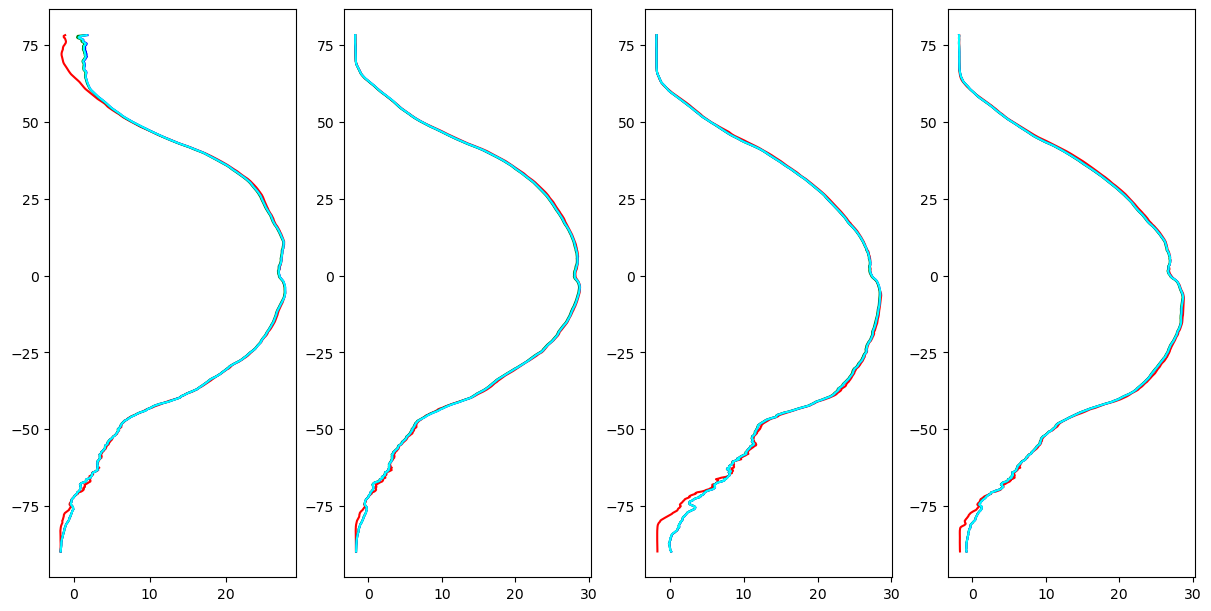

In [79]:
ds_static = xr.open_dataset('/glade/derecho/scratch/turuncu/data/static.nc')
lsm = ds_static.lsm.isel(valid_time=0)

fig, ax = plt.subplots(1, 4, figsize=(12, 6), layout='constrained')
x = ds_era5.latitude.values

indx = 0
for label, val in months.items():
    print(label, f"{val:02d}")
    # Load datasets
    ds_oisst= xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_oisst/oisst_35d_remap_bil.nc")).squeeze(drop=True)
    ds_datm = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_datm/ocn_merged_35d_remap_bil_daily.nc")).rename({'SST': 'sst'})
    ds_aur1 = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora/ocn_merged_35d_remap_bil_daily.nc")).rename({'SST': 'sst'})
    ds_aur2 = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_two_way/ocn_merged_35d_remap_bil_daily.nc")).rename({'SST': 'sst'})

    # Create mask
    dmask = ds_datm.sst.notnull()

    # Observation, OISST
    data_oisst_mean = ds_oisst.sst.where(dmask).weighted(ds_era5.weights).mean(["longitude"]).mean(["time"])
    data_oisst = ds_oisst.sst.where(dmask).weighted(ds_era5.weights).mean(["longitude"])
    data_oisst_ano = (data_oisst-data_oisst_mean).mean(["time"])
    im0 = ax[indx].plot(data_oisst_mean, x, color='red', label="ALT")

    # MOM6: ERA5 forced
    data_datm_mean = ds_datm.sst.where(dmask).weighted(ds_era5.weights).mean(["longitude"]).mean(["time"])
    data_datm = ds_datm.sst.where(dmask).weighted(ds_era5.weights).mean(["longitude"])
    data_datm_ano = (data_datm-data_datm_mean).mean(["time"])
    im1 = ax[indx].plot(data_datm_mean, x, color='green', label="DATM")

    # MOM6: Aurora forced (1-way)
    data_aur1_mean = ds_aur1.sst.where(dmask).weighted(ds_era5.weights).mean(["longitude"]).mean(["time"])
    data_aur1 = ds_aur1.sst.where(dmask).weighted(ds_era5.weights).mean(["longitude"])
    data_aur1_ano = (data_aur1-data_aur1_mean).mean(["time"])
    im2 = ax[indx].plot(data_aur1_mean, x, color='blue', label="AURORA 1w")

    # MOM6: Aurora forced (2-way)
    data_aur2_mean = ds_aur2.sst.where(dmask).weighted(ds_era5.weights).mean(["longitude"]).mean(["time"])
    data_aur2 = ds_aur2.sst.where(dmask).weighted(ds_era5.weights).mean(["longitude"])
    data_aur2_ano = (data_aur2-data_aur2_mean).mean(["time"])
    im3 = ax[indx].plot(data_aur2_mean, x, color='cyan', label="AURORA 2w")

    indx = indx+1

In [22]:
# Data frame
df = pd.DataFrame(
    columns=[
        "Month",
        "Simulation",
        "Region",
        "RMSE",
        "NRMSE_STD",
        "NRMSE_MEAN",
        "NRMSE_MINMAX",
        "NRMSE_QUANTILE",
        "Correlation"
    ]
)

# Loop over months
data_list = []
for label, val in months.items():
    print(f"Process {label}")

    # Load datasets
    ds_era5_daily = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_era5/era5_35d_sst_daily.nc")).rename({'valid_time': 'time'})
    ds_oisst_daily= xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_oisst/oisst_35d_remap_bil.nc")).isel(zlev=0)
    ds_datm_daily = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_datm/ocn_merged_35d_remap_bil_daily.nc"))
    ds_aur1_daily = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora/ocn_merged_35d_remap_bil_daily.nc"))
    ds_aur2_daily = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_two_way/ocn_merged_35d_remap_bil_daily.nc"))

    ds_era5_daily = ds_era5_daily.reindex(latitude=ds_era5_daily.latitude[::-1])
    ds_oisst_daily= ds_oisst_daily.reindex(latitude=ds_oisst_daily.latitude[::-1])
    ds_datm_daily = ds_datm_daily.reindex(latitude=ds_datm_daily.latitude[::-1])
    ds_aur1_daily = ds_aur1_daily.reindex(latitude=ds_aur1_daily.latitude[::-1])
    ds_aur2_daily = ds_aur2_daily.reindex(latitude=ds_aur2_daily.latitude[::-1])

    # Calculate weights
    weights = get_lat_weights(ds_era5_daily)
    weights2d = xr.DataArray(np.tile(weights.values[:,np.newaxis], (1, ds_era5_daily.longitude.size)))
    ds_era5_daily["weights"] = (("latitude", "longitude"), weights2d.data)
    weights = np.cos(np.deg2rad(ds_era5_daily.latitude))
    weights2d = xr.DataArray(np.tile(weights.values[:,np.newaxis], (1, ds_era5_daily.longitude.size)))
    ds_era5_daily["weights2"] = (("latitude", "longitude"), weights2d.data)

    # Loop over regions and calculate statistics
    for reg, pos in region_list.items():
        print(f"Process {reg}")

        # Get region extent
        lat_min = regions[reg]['lat_min']
        lat_max = regions[reg]['lat_max']
        lon_min = regions[reg]['lon_min']
        lon_max = regions[reg]['lon_max']

        # Subset datasets
        ds_era5_subset = ds_era5_daily.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
        ds_oisst_subset= ds_oisst_daily.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
        ds_datm_subset = ds_datm_daily.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
        ds_aur1_subset = ds_aur1_daily.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
        ds_aur2_subset = ds_aur2_daily.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))

        # Mask datasets
        mask = ~np.isnan(ds_oisst_subset.sst.isel(time=0).values) & ~np.isnan(ds_datm_subset.SST.isel(time=0).values)

        # Prepare data (area weighted mean)
        data_era5 = ds_era5_subset.sst.where(mask).weighted(ds_era5_subset.weights).mean(dim=["longitude", "latitude"])-273.15
        data_oisst= ds_oisst_subset.sst.where(mask).weighted(ds_era5_subset.weights).mean(dim=["longitude", "latitude"])
        data_datm = ds_datm_subset.SST.where(mask).weighted(ds_era5_subset.weights).mean(dim=["longitude", "latitude"])
        data_aur1 = ds_aur1_subset.SST.where(mask).weighted(ds_era5_subset.weights).mean(dim=["longitude", "latitude"])
        data_aur2 = ds_aur2_subset.SST.where(mask).weighted(ds_era5_subset.weights).mean(dim=["longitude", "latitude"])
        
        # Calculate correlation and RMSE
        data = {
            "ERA5": data_era5,
            "DATM": data_datm,
            "AURORA 1": data_aur1,
            "AURORA 2": data_aur2
        }
        for label, d in data.items():
            corr = ma.corrcoef(d.values, data_oisst.values)[0, 1]
            rmse = np.sqrt(np.mean((d.values - data_oisst.values) ** 2))
            #print(f"{label} CORR, RMSE = {corr:.4f}, {rmse:.4f}")
            data_list.append(
                {
                    "month": val,
                    "simulation": label,
                    "region": reg,
                    "rmse": rmse,
                    "corr": corr
                }
            )
# Convert to data frame
df = pd.DataFrame.from_records(data_list)
df = df.set_index(["month", "simulation", "region"])

# Convert to dataset
ds = xr.Dataset.from_dataframe(df)
ds.to_netcdf("stats_sst.nc")

Process JAN
Process Global
Process Nino 1+2
Process Nino 3
Process Nino 4
Process Nino 3.4
Process Indian Ocean
Process Western Pacific Ocean
Process Eastern Pacific Ocean
Process APR
Process Global
Process Nino 1+2
Process Nino 3
Process Nino 4
Process Nino 3.4
Process Indian Ocean
Process Western Pacific Ocean
Process Eastern Pacific Ocean
Process JUL
Process Global
Process Nino 1+2
Process Nino 3
Process Nino 4
Process Nino 3.4
Process Indian Ocean
Process Western Pacific Ocean
Process Eastern Pacific Ocean
Process OCT
Process Global
Process Nino 1+2
Process Nino 3
Process Nino 4
Process Nino 3.4
Process Indian Ocean
Process Western Pacific Ocean
Process Eastern Pacific Ocean


Text(-0.15, -1.0, 'Starting Month for 35d Long Simulations')

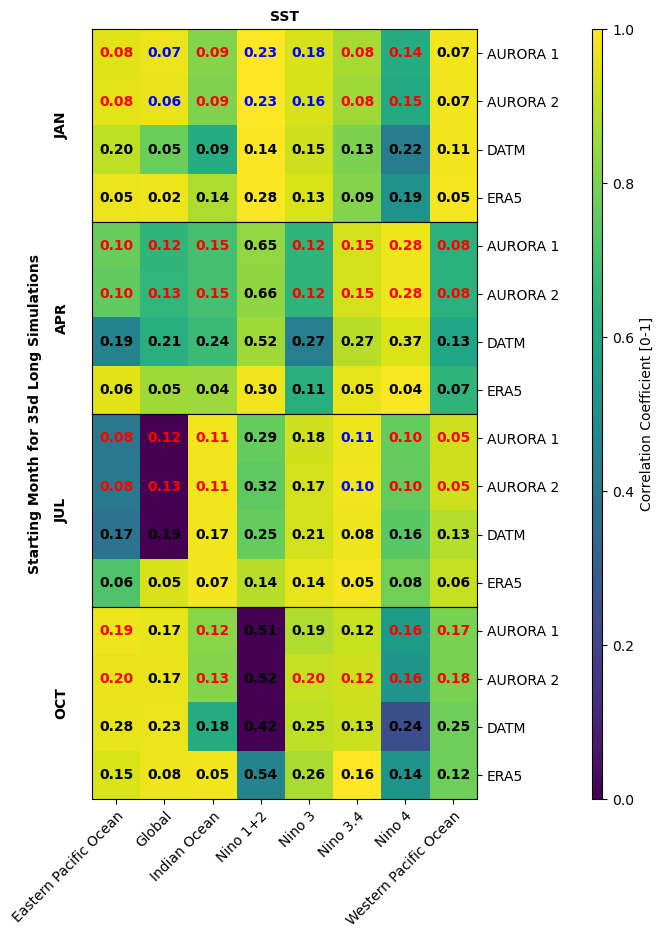

In [23]:
ds = xr.open_dataset("stats_sst.nc")

fig, ax = plt.subplots(4, 1, figsize=(10,10), gridspec_kw={'wspace': 0.0, 'hspace': 0.0})

irow = 0
for label, val in months.items():
    # Set list of regions and simulations
    regions = ds.region.values
    simulations = ds.simulation.values
    indx_era5 = list(simulations).index('ERA5')

    # Plot
    data_corr = ds.corr.sel(month=val)
    im1 = ax[irow].imshow(data_corr, cmap="viridis", vmin=0, vmax=1)
    ax[irow].set_xticklabels([])
    ax[irow].set_xlabel('')
    ax[irow].yaxis.tick_right()
    ax[irow].tick_params(axis='y', labelright=True, labelleft=False)
    ax[irow].set_yticks(range(len(simulations)), labels=simulations, fontsize=10)
    ax[irow].text(-0.08, 0.5, label, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10, transform=ax[irow].transAxes)
    if irow == 0:
        ax[irow].set_title("SST", fontweight='bold', fontsize=10)
    else:
        ax[irow].set_title("")

    # Add RMSE
    j = 0
    for r in regions:
        i = 0
        data_rmse_datm = ds.rmse.sel(month=val, region=r, simulation="DATM").values
        data_corr_datm = ds.corr.sel(month=val, region=r, simulation="DATM").values
        for s in simulations:
            data_rmse = ds.rmse.sel(month=val, region=r, simulation=s).values
            data_corr = ds.corr.sel(month=val, region=r, simulation=s).values
            color = "black"
            if s != "ERA5" and s != "DATM":
                if data_rmse < data_rmse_datm and data_corr > data_corr_datm:
                    color = "red"
                if data_rmse > data_rmse_datm and data_corr > data_corr_datm:
                    color = "blue"
            text = ax[irow].text(j, i, f'{data_rmse:.2f}', ha="center", va="center", fontweight='bold', fontsize=10, color=color)
            i=i+1
        j=j+1

    # Add region labels
    if irow == 3:
        for icol in range(0,4):
            ax[irow].set_xticks(range(len(regions)), labels=regions, rotation=45, ha="right", rotation_mode="anchor")

    irow = irow+1

cbar_ax = fig.add_axes([0.82, 0.11, 0.01, 0.77])
fig.colorbar(ax[0].images[0], cax=cbar_ax, label='Correlation Coefficient [0-1]')

ax[0].text(-0.15, -1.0, 'Starting Month for 35d Long Simulations', rotation=90, ha='center', va='center', fontweight='bold', fontsize=10, transform=ax[0].transAxes)

-1.8 32.0275
-1.8 31.1925
-1.8 33.3825
-1.8 33.1175


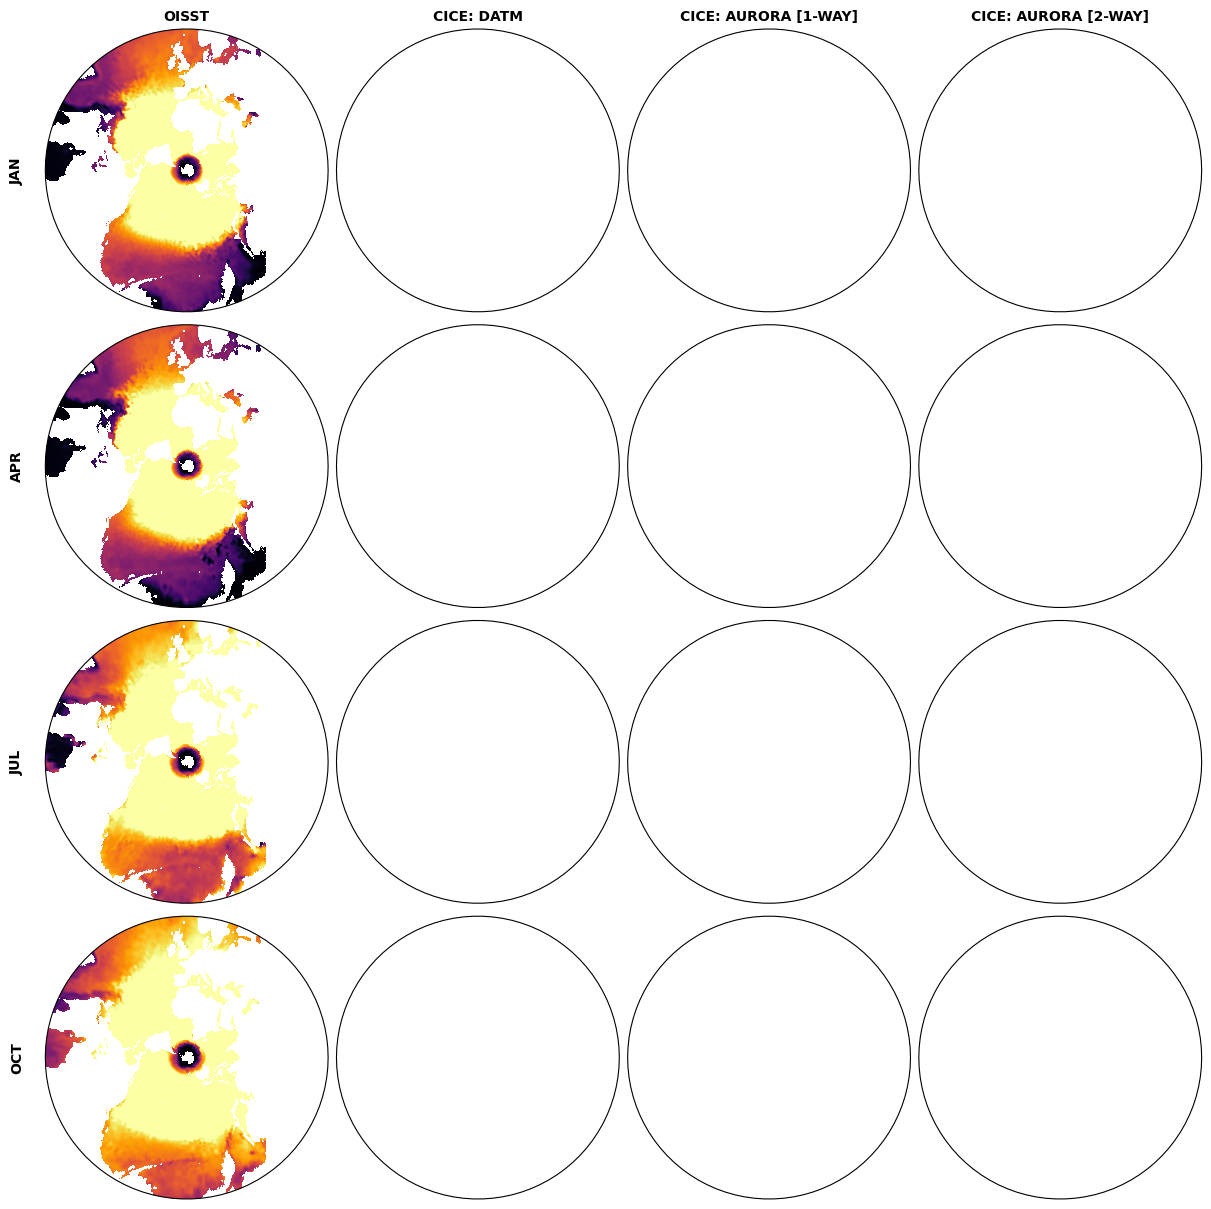

In [55]:
# Make circular boundary for polar stereographic circular plots
import matplotlib.path as mpath
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

# Create figure
proj  = ccrs.SouthPolarStereo()
fig, ax = plt.subplots(4, 4, figsize=(12, 12), layout='constrained', subplot_kw={'projection': proj})

irow = 0
for label, val in months.items():
    # Load datasets
    ds_oisst = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_oisst/oisst_35d_remap_bil.nc")).isel(zlev=0)
    ds_datm  = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_datm/ocn_merged_35d_remap_bil.nc")).rename({'SST': 'sst'})

    # OISST
    data_oisst = ds_oisst.sst.isel(time=0)
    #print(data_oisst.min().values, data_oisst.max().values)
    #im0 = data_oisst.plot(ax=ax[irow,0], transform=ccrs.PlateCarree(), vmin=-2, vmax=15, cmap='inferno', add_colorbar=False)
    #ax[irow,0].coastlines(linewidth=0.5)
    #ax[irow,0].set_extent([-180, 180, -50, -90], ccrs.PlateCarree())
    
    fig.colorbar(im0, ax=ax[irow,0], pad=0.08, aspect=20, shrink=0.9, label='SST [degC]')

    #data_oisst = ds_oisst_mean.ice.isel(time=0)
    #data_oisst = ds_oisst_mean.ice_conc.isel(time=0)
    #data_oisst = data_oisst.where(data_oisst > thold)
    #data_oisst = data_oisst/100.0
    #data_obs = ds_ice_mean.ice_conc.isel(time=0)
    #data_obs = data_obs.where(data_obs > thold)
    #data_obs = data_obs/100.0
    #im0 = data_obs.plot(ax=ax[irow,0], transform=ccrs.PlateCarree(), vmin=0, vmax=1, cmap='Blues_r', add_colorbar=False)


    # CICE: ERA5 forced
    #data_datm = ds_datm.aice_d.isel(time=0)
    #data_datm = data_datm.where(data_datm > thold)
    #data_datm = data_datm-data_oisst
    #im1 = data_datm.plot(ax=ax[irow,1], transform=ccrs.PlateCarree(), vmin=-0.1, vmax=0.1, cmap='RdBu_r', add_colorbar=False)
    #im1 = data_datm.plot(ax=ax[irow,1], transform=ccrs.PlateCarree(), vmin=0, vmax=1, cmap='Blues_r', add_colorbar=False)
    #ax[irow,1].set_extent([-180, 180, -50, -90], ccrs.PlateCarree())
    #ax[irow,1].coastlines(linewidth=0.5)

    # CICE: Aurora forced (1-way)
    #data_aur1 = ds_aur1_mean.aice_d.isel(time=0)
    #data_aur1 = data_aur1.where(data_aur1 > thold)
    #data_aur1 = data_aur1-data_oisst
    #im2 = data_aur1.plot(ax=ax[irow,2], transform=ccrs.PlateCarree(), vmin=-0.1, vmax=0.1, cmap='RdBu_r', add_colorbar=False)
    #ax[irow,2].set_extent([-180, 180, -50, -90], ccrs.PlateCarree())
    #ax[irow,2].coastlines(linewidth=0.5)

    # CICE: Aurora forced (2-way)
    #data_aur2 = ds_aur2_mean.aice_d.isel(time=0)
    #data_aur2 = data_aur2.where(data_aur2 > thold)
    #data_aur2 = data_aur2-data_oisst
    #im3 = data_aur1.plot(ax=ax[irow,3], transform=ccrs.PlateCarree(), vmin=-0.1, vmax=0.1, cmap='RdBu_r', add_colorbar=False)
    #ax[irow,3].coastlines(linewidth=0.5)
    #ax[irow,3].set_extent([-180, 180, -50, -90], ccrs.PlateCarree())
    #fig.colorbar(im3, ax=ax[irow,3], pad=0.08, aspect=20, shrink=0.9, label='Sea-ice Concentration Diff [1]')

    # Labels
    if irow == 0:
        ax[irow,0].set_title("OISST", fontweight='bold', fontsize=10)
        ax[irow,1].set_title("CICE: DATM", fontweight='bold', fontsize=10)
        ax[irow,2].set_title("CICE: AURORA [1-WAY]", fontweight='bold', fontsize=10)
        ax[irow,3].set_title("CICE: AURORA [2-WAY]", fontweight='bold', fontsize=10)
    else:
        ax[irow,0].set_title("")
        ax[irow,1].set_title("")
        ax[irow,2].set_title("")
        ax[irow,3].set_title("")

    ax[irow,0].text(-0.1, 0.5, f"{label}", transform=ax[irow,0].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

    irow = irow+1
    break